## Problem statement
**Analyze Retail Sales data to identify profit drivers, loss areas, and business performance trends.**

## Data Loading

In [1]:
 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv
/kaggle/input/datasets/mamtapathak/superstore-datasets/sample superstore.xls


In [2]:
import pandas as pd 


In [3]:
df = pd.read_csv('/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv', encoding = 'latin1')

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Cleaning

In [5]:
# convert date columns from text to datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [7]:

df = df[[
    'Order ID',
    'Order Date',
    'Ship Date',
    'Ship Mode',
    'Segment',
    'Region',
    'Category',
    'Sub-Category',
    'Product Name',
    'Sales',
    'Quantity',
    'Discount',
    'Profit'
]]


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      9994 non-null   object        
 1   Order Date    9994 non-null   datetime64[ns]
 2   Ship Date     9994 non-null   datetime64[ns]
 3   Ship Mode     9994 non-null   object        
 4   Segment       9994 non-null   object        
 5   Region        9994 non-null   object        
 6   Category      9994 non-null   object        
 7   Sub-Category  9994 non-null   object        
 8   Product Name  9994 non-null   object        
 9   Sales         9994 non-null   float64       
 10  Quantity      9994 non-null   int64         
 11  Discount      9994 non-null   float64       
 12  Profit        9994 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(7)
memory usage: 1015.1+ KB


In [9]:
df.head(10)

df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Region',
       'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

## Exploratory Data Analysis  (EDA)

### Regional Analysis

<Axes: xlabel='Region'>

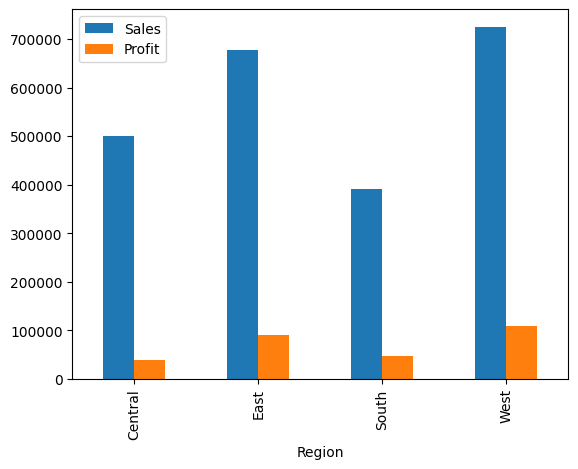

In [10]:
# which region is profitable (biggest profit)

df.groupby('Region')[['Sales', 'Profit']].sum().plot(kind='bar')

### Discount Analysis

<Axes: xlabel='Discount'>

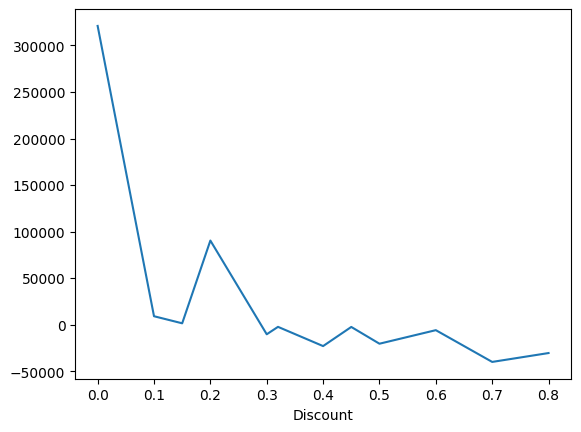

In [11]:
# Discount impact on profit -  why profit changes, not just it happens - 
# Testing - does higher discount = lower profit? - At what discount level does profit drops?
# Discount vs Profit analysis
# .sort_index ( in this case ) - Arrange results by the index values(not random)- discount - 0.00...

df.groupby('Discount')['Profit'].sum().sort_index().plot(kind='line')

### Category Analysis

<Axes: xlabel='Category'>

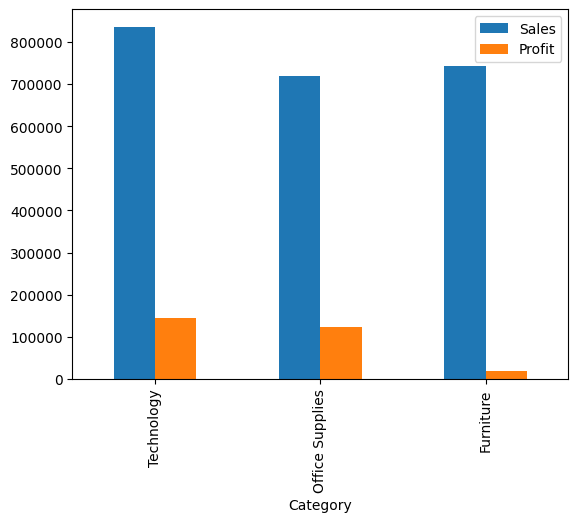

In [12]:
# category performance (sales(revenue) + profit by category)
# what type of business is actually driving profit
# measures overall contribution - big categories naturally wins   asc=F (biggest first)

df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False).plot(kind='bar')


In [13]:
# efficiency check - how much profit each single transaction generates on avg for each category
# which category makes more money overall
# which category is efficient per sale - shows hidden problem


df.groupby('Category')['Profit'].mean().sort_values(ascending=False)

Category
Technology         78.752002
Office Supplies    20.327050
Furniture           8.699327
Name: Profit, dtype: float64

### Product Analysis

<Axes: ylabel='Product Name'>

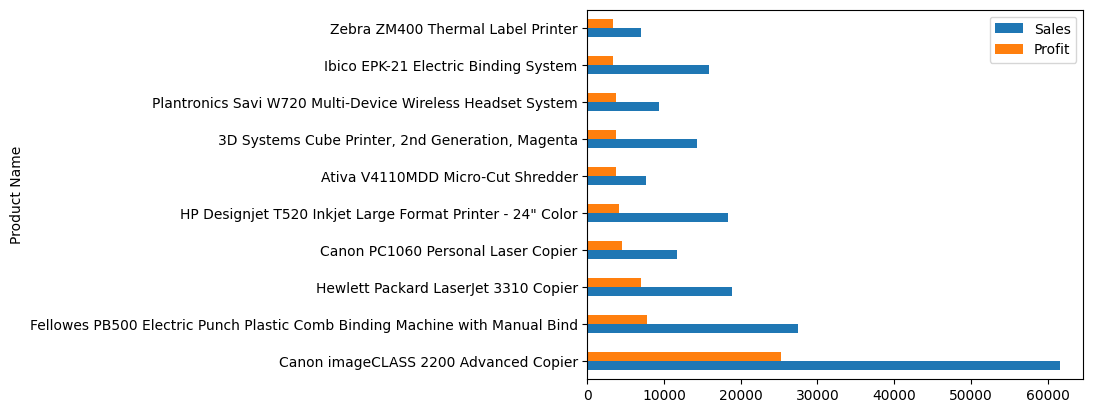

In [14]:
# product level analysis-
# what exact product make or destory profits
# Top profitable product   (barh = bar horizontal)

df.groupby('Product Name')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False).head(10).plot(kind='barh')

In [15]:
# worst performing product

df.groupby('Product Name')[['Sales', 'Profit']].sum().sort_values('Profit').head(10)

,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581


### Time Analysis

In [16]:
# Monthly trend analysis - Time Insight 
# when does the business make money overtime
# create monthly sales - business performance overtime

# group/convert order date to month - making new column
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')[['Sales', 'Profit']].sum()
monthly_sales

,Sales,Profit
Month,,
2014-01,14236.8950,2450.1907
2014-02,4519.8920,862.3084
2014-03,55691.0090,498.7299
2014-04,28295.3450,3488.8352
2014-05,23648.2870,2738.7096
2014-06,34595.1276,4976.5244
2014-07,33946.3930,-841.4826
2014-08,27909.4685,5318.1050
2014-09,81777.3508,8328.0994


## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

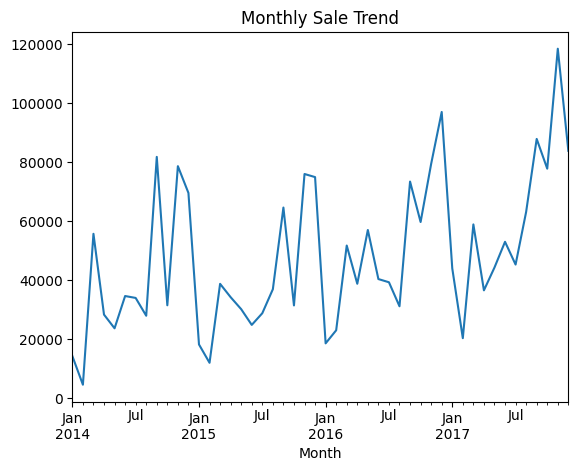

In [17]:
# visualize

import matplotlib.pyplot as plt 

monthly_sales['Sales'].plot()
plt.title("Monthly Sale Trend")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

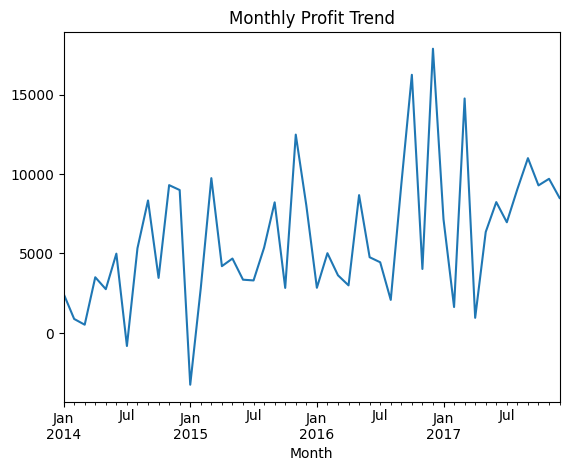

In [18]:
monthly_sales['Profit'].plot()
plt.title("Monthly Profit Trend")
plt.show

## Key Insight
**• Region performance imbalance
 • Furniture margin problem
 • Discount-driven profit loss
 • Profit concentration in few products
 • Sales ≠ Profit relationship**

## Recommendation
**• Reduce discounts above 20–30%
 • Fix Furniture pricing strategy
 • Focus on high-margin products (copiers/printers)
 • Improve Central region profitability
 • Optimize product mix**

## Conclusion
**Profitability is driven more by pricing efficiency and product mix than total sales volume.**
